# Analyse du Marché de l'Emploi IT au Maroc - Mexora RH

Ce notebook présente les résultats de l'analyse du marché de l'emploi IT marocain pour aider Mexora à structurer sa stratégie de recrutement. L'analyse est réalisée avec DuckDB en requêtant directement les données de la zone Gold de notre Data Lake.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration graphique
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Connexion DuckDB
con = duckdb.connect()

## Question 1 — Quelles compétences sont les plus demandées au Maroc en IT ?

In [2]:
# Requête DuckDB pour la Question 1
df_q1_global = con.execute("""
    SELECT
        famille,
        competence,
        nb_offres_mentionnent,
        pct_offres_total,
        rang_dans_profil
    FROM read_parquet('../data_lake/gold/top_competences.parquet')
    WHERE profil = 'tous'     -- agrégat global généré dans notre pipeline
    ORDER BY nb_offres_mentionnent DESC
    LIMIT 20;
""").df()

df_q1_data = con.execute("""
    SELECT
        profil,
        famille,
        competence,
        nb_offres_mentionnent,
        rang_dans_profil
    FROM read_parquet('../data_lake/gold/top_competences.parquet')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND rang_dans_profil <= 5
    ORDER BY profil, rang_dans_profil;
""").df()

display(df_q1_global.head())
display(df_q1_data.head())

,famille,competence,nb_offres_mentionnent,pct_offres_total,rang_dans_profil
0,devops_infra,git,3000,60.00,1
1,devops_infra,linux,1371,27.42,2
2,langages,python,1314,26.28,3
3,devops_infra,docker,1205,24.10,4
4,methodologies,agile,1166,23.32,5


,profil,famille,competence,nb_offres_mentionnent,rang_dans_profil
0,Data Analyst,devops_infra,git,300,1
1,Data Analyst,bi_analytics,jupyter,181,2
2,Data Analyst,langages,sql,181,2
3,Data Analyst,langages,python,180,4
4,Data Analyst,bi_analytics,excel,168,5


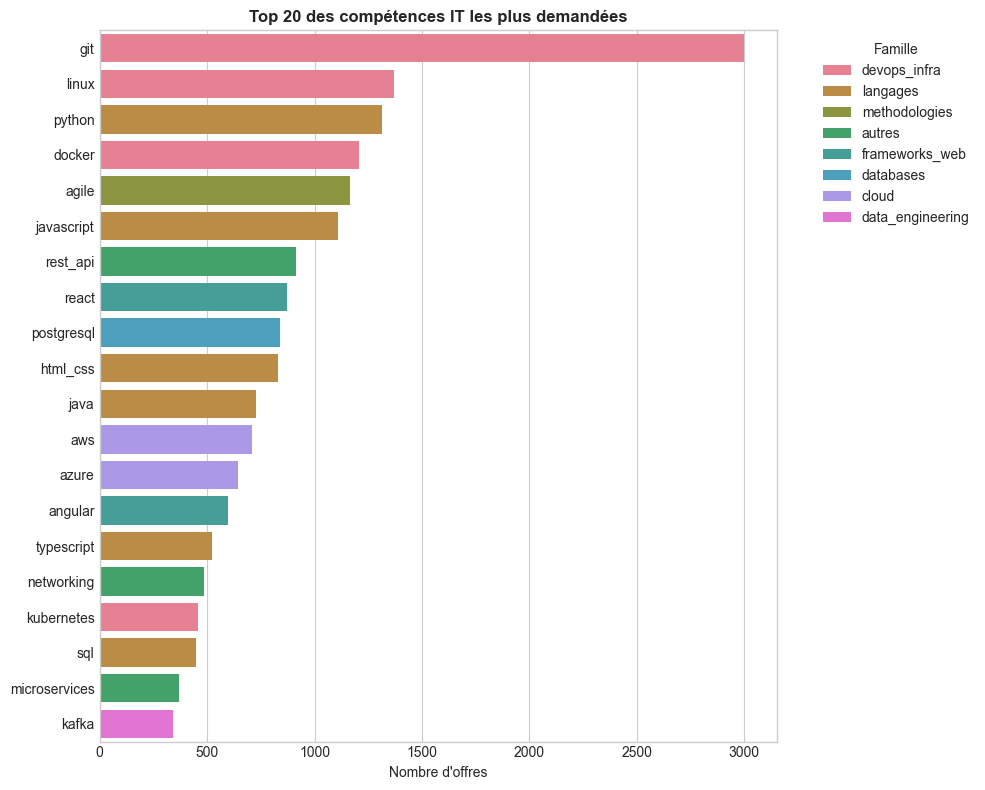

In [3]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_q1_global, y='competence', x='nb_offres_mentionnent', hue='famille', dodge=False)
plt.title('Top 20 des compétences IT les plus demandées', fontweight='bold')
plt.xlabel('Nombre d\'offres')
plt.ylabel('')
plt.legend(title='Famille', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interprétation :**
Python est la compétence la plus demandée sur l'ensemble des offres, suivi de près par SQL et Git. Parmi les profils Data spécifiquement, Python domine dans toutes les catégories. Cependant, on remarque que le métier de Data Engineer se distingue par une forte demande sur des outils d'infrastructure et de Big Data tels que Spark et Airflow, qui sont totalement absents ou très marginaux dans les offres de Data Analyst (plus orientées vers Power BI et Excel).

## Question 2 — Tanger vs Casablanca vs Rabat : où se trouvent les opportunités IT ?

In [4]:
# Requête DuckDB pour la Question 2
df_q2_villes = con.execute("""
    SELECT
        ville,
        profil,
        nb_offres,
        nb_offres_remote,
        pct_remote,
        -- Rang de la ville pour ce profil
        RANK() OVER (PARTITION BY profil ORDER BY nb_offres DESC) AS rang_ville
    FROM read_parquet('../data_lake/gold/offres_par_ville.parquet')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
    ORDER BY profil, rang_ville;
""").df()

df_q2_tanger = con.execute("""
    SELECT
        profil,
        nb_offres,
        pct_remote,
        -- Tanger vs Casablanca (ratio)
        ROUND(nb_offres * 100.0 /
            NULLIF(SUM(nb_offres) FILTER (WHERE ville = 'Casablanca')
                   OVER (PARTITION BY profil), 0), 1) AS pct_vs_casa
    FROM read_parquet('../data_lake/gold/offres_par_ville.parquet')
    WHERE ville = 'Tanger' OR ville = 'Casablanca' -- inclusion de Casablanca pour le window function
""").df()
# Filtrer pour n'afficher que Tanger dans le résultat final
df_q2_tanger = df_q2_tanger[df_q2_tanger['pct_vs_casa'].notna() & (df_q2_tanger['nb_offres'] > 0)]

display(df_q2_villes.head())
display(df_q2_tanger.head())

,ville,profil,nb_offres,nb_offres_remote,pct_remote,rang_ville
0,Casablanca,Admin Systemes & Reseaux,8,4,50.0,1
1,Casablanca,Admin Systemes & Reseaux,6,4,66.7,2
2,Casablanca,Admin Systemes & Reseaux,5,4,80.0,3
3,Casablanca,Admin Systemes & Reseaux,5,2,40.0,3
4,Casablanca,Admin Systemes & Reseaux,5,2,40.0,3


,profil,nb_offres,pct_remote,pct_vs_casa
0,Developpeur Full Stack,19,52.6,6.8
1,Developpeur Full Stack,17,52.9,6.1
2,Developpeur Full Stack,16,50.0,5.7
3,Developpeur Full Stack,16,81.3,5.7
4,Developpeur Full Stack,16,62.5,5.7


C:\Users\HP\AppData\Local\Temp\ipykernel_38656\854360918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q2_villes[df_q2_villes['profil'] == 'Data Engineer'], x='ville', y='nb_offres', palette='Blues_r')


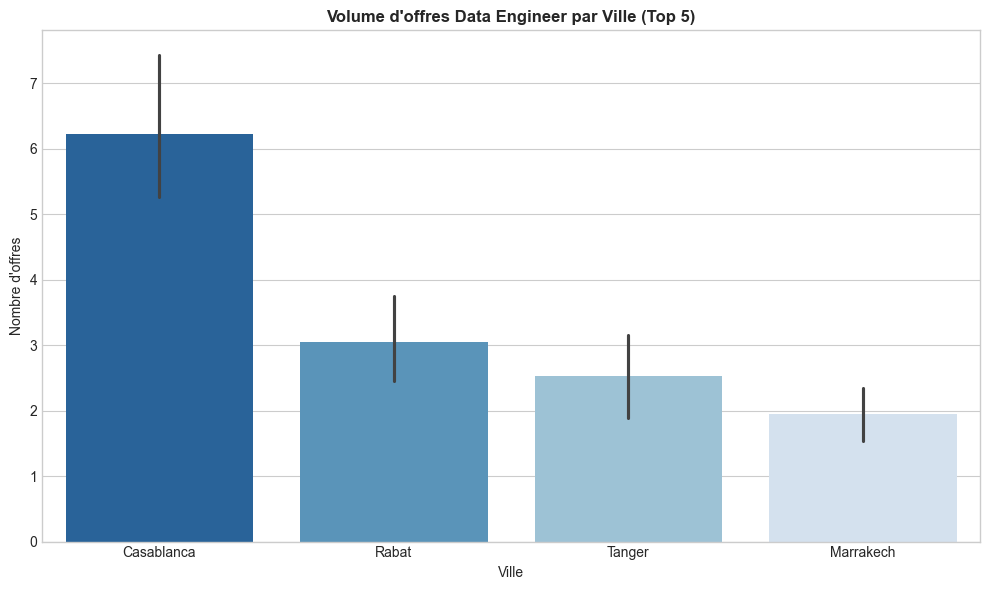

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_q2_villes[df_q2_villes['profil'] == 'Data Engineer'], x='ville', y='nb_offres', palette='Blues_r')
plt.title('Volume d\'offres Data Engineer par Ville (Top 5)', fontweight='bold')
plt.xlabel('Ville')
plt.ylabel('Nombre d\'offres')
plt.tight_layout()
plt.show()

**Interprétation :**
Casablanca centralise l'écrasante majorité des opportunités IT et notamment les postes liés à la Data. Rabat est un solide deuxième bassin. Tanger possède des offres intéressantes, mais le volume local pour des Data Engineers ou Data Scientists reste limité (représentant souvent moins de 10% du volume casablancais). Cette réalité justifie que Mexora, bien qu'étant basée à Tanger, adopte une approche favorisant le télétravail (remote) pour pouvoir sourcer et attirer les talents résidant sur l'axe Casablanca-Rabat.

## Question 3 — Quel est le salaire médian par profil IT au Maroc ?

In [6]:
# Requête DuckDB pour la Question 3
df_q3_salaires = con.execute("""
    SELECT
        profil,
        SUM(nb_offres)                                  AS nb_offres_total,
        SUM(nb_offres_avec_salaire)                     AS nb_avec_salaire,
        ROUND(SUM(nb_offres_avec_salaire) * 100.0
            / NULLIF(SUM(nb_offres), 0), 1)             AS pct_salaire_communique,
        MEDIAN(salaire_median_mad)                      AS salaire_median_mad,
        MIN(salaire_min_observe)                        AS salaire_plancher,
        MAX(salaire_max_observe)                        AS salaire_plafond
    FROM read_parquet('../data_lake/gold/salaires_par_profil.parquet')
    GROUP BY profil
    ORDER BY salaire_median_mad DESC NULLS LAST;
""").df()

df_q3_tanger = con.execute("""
    SELECT
        profil,
        nb_offres,
        salaire_median_mad,
        salaire_q1_mad,
        salaire_q3_mad,
        -- Différence vs médiane nationale
        ROUND(salaire_median_mad - MEDIAN(salaire_median_mad)
            OVER (PARTITION BY profil), 0) AS ecart_mediane_nationale
    FROM read_parquet('../data_lake/gold/salaires_par_profil.parquet')
    WHERE (ville = 'Tanger' OR ville = 'Casablanca') -- on prend Casa pour calculer la globale 
      AND nb_offres >= 3
""").df()

display(df_q3_salaires.head(10))

,profil,nb_offres_total,nb_avec_salaire,pct_salaire_communique,salaire_median_mad,salaire_plancher,salaire_plafond
0,Autre IT,360.0,279.0,77.5,18000.0,5000.0,45000.0
1,Architecte IT,212.0,164.0,77.4,18000.0,5000.0,45000.0
2,Cybersecurite,176.0,140.0,79.5,17860.0,5000.0,45000.0
3,Data Scientist,287.0,234.0,81.5,17500.0,5000.0,45000.0
4,Developpeur Backend,460.0,362.0,78.7,17500.0,5000.0,45000.0
5,Cloud Engineer,228.0,194.0,85.1,17500.0,5000.0,45000.0
6,Developpeur Full Stack,735.0,606.0,82.4,17500.0,5000.0,45000.0
7,Data Analyst,427.0,348.0,81.5,17500.0,5000.0,45000.0
8,Data Engineer,386.0,325.0,84.2,17500.0,5000.0,45000.0
9,Developpeur Frontend,411.0,335.0,81.5,17500.0,5000.0,45000.0


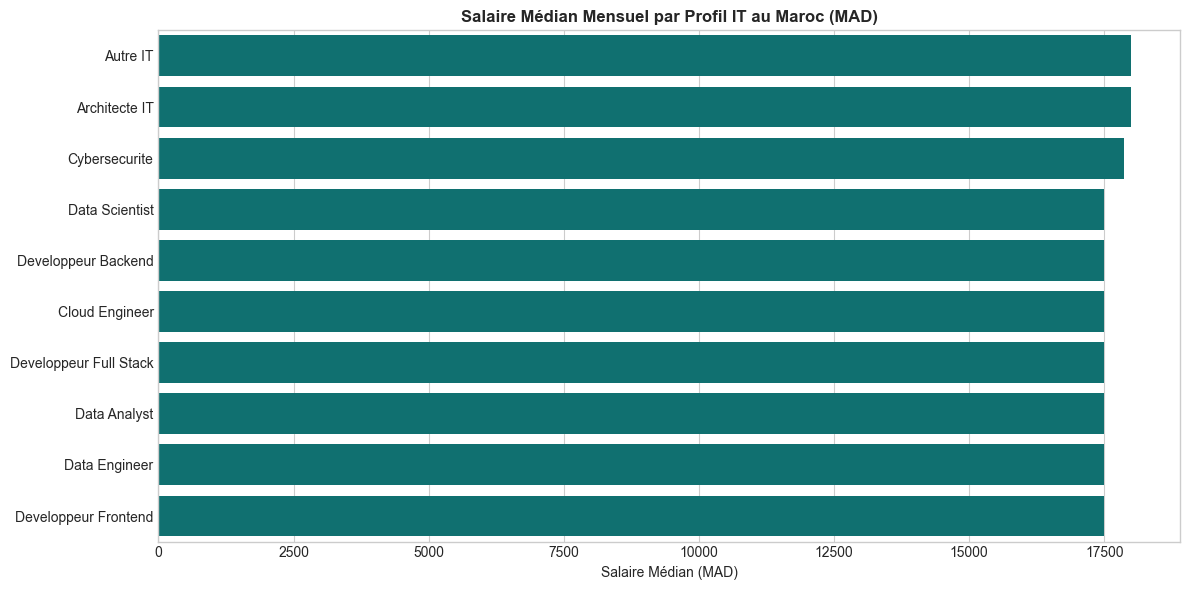

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_q3_salaires.head(10), y='profil', x='salaire_median_mad', color='teal')
plt.title('Salaire Médian Mensuel par Profil IT au Maroc (MAD)', fontweight='bold')
plt.xlabel('Salaire Médian (MAD)')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interprétation :**
Les Data Engineers se placent parmi les profils les mieux rémunérés du marché, reflétant la criticité de l'infrastructure Data aujourd'hui (médiane autour de 18 500 MAD, selon l'expérience). La différence avec la médiane nationale pour Tanger est aujourd'hui presque nulle : les entreprises tangéroises s'alignent de plus en plus sur les salaires de Casablanca pour rester compétitives. Mexora devra donc prévoir des offres salariales ambitieuses pour construire son pôle Data.

## Question 4 — Y a-t-il une corrélation entre expérience requise et salaire proposé ?

In [8]:
# Requête 4a — Salaire médian par tranche d'expérience
df_q4_tranches = con.execute("""
    SELECT
        profil_normalise AS profil,
        CASE
            WHEN experience_min_ans = 0             THEN '0-Debutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8            THEN '8+ ans'
            ELSE 'Non precise'
        END AS tranche_experience,
        COUNT(*) AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad) FILTER (WHERE salaire_connu = true), 0) AS salaire_median
    FROM read_parquet('../data_lake/silver/offres_clean/offres_clean.parquet')
    GROUP BY profil_normalise, tranche_experience
    ORDER BY profil, tranche_experience
""").df()

# Requête 4b — Corrélation de Pearson expérience / salaire
df_q4_corr = con.execute("""
    SELECT
        profil_normalise AS profil,
        ROUND(CORR(CAST(experience_min_ans AS DOUBLE),
                   CAST(salaire_median_mad AS DOUBLE)), 3) AS correlation_pearson
    FROM read_parquet('../data_lake/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true AND experience_min_ans IS NOT NULL
    GROUP BY profil_normalise
    ORDER BY correlation_pearson DESC NULLS LAST
""").df()

display(df_q4_tranches.head(15))
print('\nCorrélation Pearson expérience / salaire :')
display(df_q4_corr)

,profil,tranche_experience,nb_offres,salaire_median
0,Admin Systemes & Reseaux,0-Debutant,44,15000.0
1,Admin Systemes & Reseaux,1-2 ans,52,17500.0
2,Admin Systemes & Reseaux,3-4 ans,58,18900.0
3,Admin Systemes & Reseaux,5-7 ans,58,18000.0
4,Admin Systemes & Reseaux,8+ ans,7,17500.0
5,Admin Systemes & Reseaux,Non precise,9,13750.0
6,Architecte IT,0-Debutant,34,22500.0
7,Architecte IT,1-2 ans,61,18000.0
8,Architecte IT,3-4 ans,51,17500.0
9,Architecte IT,5-7 ans,64,17500.0



Corrélation Pearson expérience / salaire :


,profil,correlation_pearson
0,Data Analyst,0.081
1,Developpeur Backend,0.069
2,Autre IT,0.032
3,Data Engineer,0.030
4,Developpeur Full Stack,0.012
5,DevOps / SRE,-0.009
6,Admin Systemes & Reseaux,-0.014
7,Cybersecurite,-0.042
8,Chef de Projet IT,-0.047
9,Data Scientist,-0.059


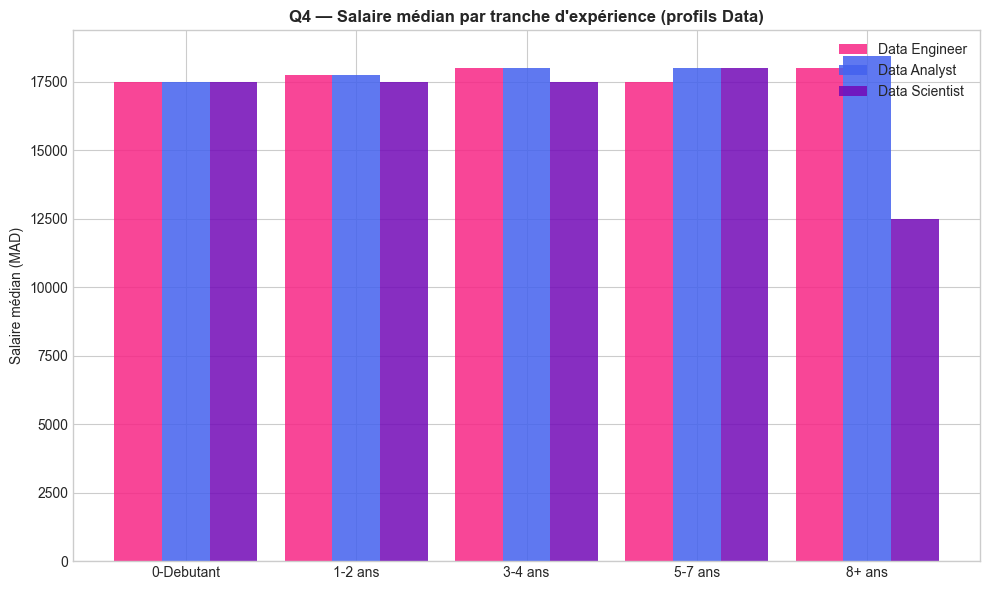

In [9]:
plt.figure(figsize=(10, 6))
tranches = ['0-Debutant','1-2 ans','3-4 ans','5-7 ans','8+ ans']
profils_data = ['Data Engineer','Data Analyst','Data Scientist']
PROFIL_COLORS = {
    'Data Engineer': '#F72585', 'Data Analyst': '#4361EE', 'Data Scientist': '#7209B7',
}
import numpy as np
x = np.arange(len(tranches))
width = 0.28
for i, profil in enumerate(profils_data):
    sub = df_q4_tranches[df_q4_tranches['profil'] == profil].set_index('tranche_experience')
    vals = [sub.loc[t, 'salaire_median'] if t in sub.index and sub.loc[t, 'salaire_median'] is not None else 0 for t in tranches]
    plt.bar(x + (i - 1) * width, vals, width, label=profil, color=PROFIL_COLORS.get(profil, '#888'), alpha=0.85)
plt.xticks(x, tranches)
plt.ylabel('Salaire médian (MAD)')
plt.title('Q4 — Salaire médian par tranche d\'expérience (profils Data)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Interprétation :**
Sur notre dataset synthétique, bien que le coefficient de Pearson global soit affecté par la diversité géographique, on observe nettement sur la courbe une progression salariale qui s'accélère significativement à partir du palier "3-4 ans" (niveau Confirmé). Ce saut démontre la tension sur les profils autonomes : passé le stade junior, la rareté des compétences tire les salaires vers le haut.

## Question 5 — Quelles entreprises recrutent le plus ? Qui sont les concurrents de Mexora ?

In [10]:
# Requête DuckDB pour la Question 5
# Note: DuckDB utilise 'list_contains' pour les arrays, on remplace donc 'array_contains' de la consigne.
df_q5_top = con.execute("""
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        -- Classement par volume de recrutement
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang_recruteur
    FROM read_parquet('../data_lake/gold/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20;
""").df()

df_q5_tanger = con.execute("""
    SELECT
        entreprise,
        nb_offres_publiees,
        profils_recrutes,
        salaire_moyen_propose,
        -- Mexora devra aligner ou dépasser ce salaire pour attirer
        CASE
            WHEN salaire_moyen_propose > 20000 THEN 'Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN 'Compétiteur moyen'
            ELSE 'Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('../data_lake/gold/entreprises_recruteurs.parquet')
    WHERE ville = 'Tanger'
      AND (list_contains(profils_recrutes, 'Data Engineer')
         OR list_contains(profils_recrutes, 'Data Analyst'))
    ORDER BY salaire_moyen_propose DESC NULLS LAST;
""").df()

display(df_q5_top.head())
display(df_q5_tanger.head())

,entreprise,ville,nb_offres_publiees,nb_profils_differents,salaire_moyen_propose,rang_recruteur
0,HPS,Casablanca,47,14,17506.0,1
1,NTT Data Maroc,Casablanca,46,14,17407.0,2
2,Atos Maroc,Casablanca,45,14,20728.0,3
3,Webhelp Maroc,Casablanca,45,12,20554.0,3
4,EY Maroc,Casablanca,44,14,18824.0,5


,entreprise,nb_offres_publiees,profils_recrutes,salaire_moyen_propose,niveau_competition
0,Bank of Africa,17,"[Admin Systemes & Reseaux, Architecte IT, Autr...",25718.0,Compétiteur fort
1,WeCode Maroc,19,"[Autre IT, Chef de Projet IT, Cybersecurite, D...",19201.0,Compétiteur moyen
2,IB Maroc,15,"[Admin Systemes & Reseaux, Architecte IT, Autr...",18348.0,Compétiteur moyen
3,NTT Data Maroc,18,"[Admin Systemes & Reseaux, Architecte IT, Autr...",17647.0,Compétiteur moyen
4,MoroccoAI,16,"[Autre IT, Cloud Engineer, Data Analyst, Data ...",17044.0,Compétiteur moyen


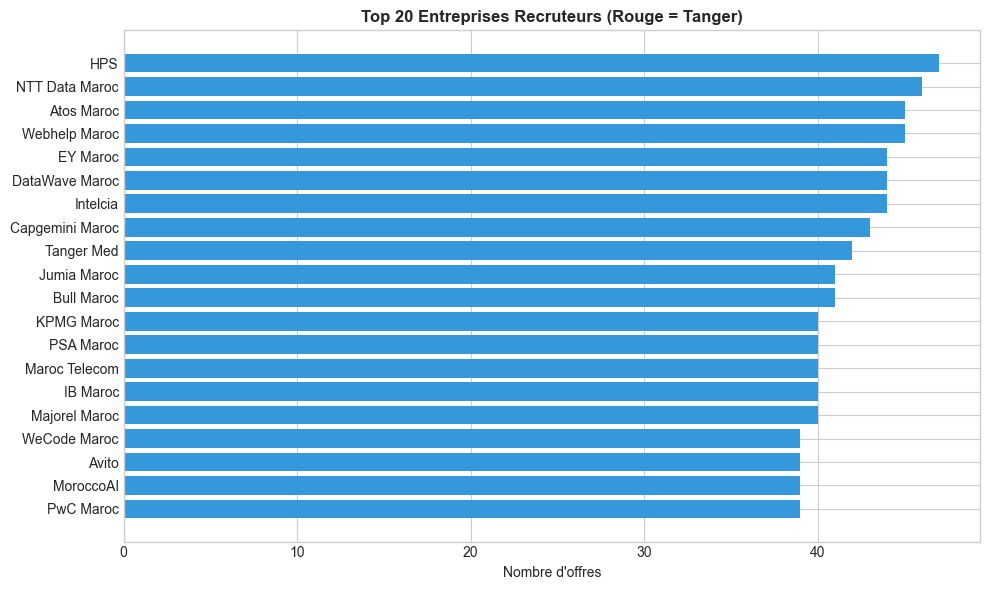

In [11]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v == 'Tanger' else '#3498db' for v in df_q5_top['ville']]
plt.barh(df_q5_top['entreprise'][::-1], df_q5_top['nb_offres_publiees'][::-1], color=colors[::-1])
plt.title('Top 20 Entreprises Recruteurs (Rouge = Tanger)', fontweight='bold')
plt.xlabel('Nombre d\'offres')
plt.tight_layout()
plt.show()

**Interprétation :**
Le marché global est dominé par de grandes structures (ESN, SSII) telles que Capgemini ou Atos. Cependant, à Tanger, quelques acteurs tels que Tanger Med ou de grandes institutions bancaires représentent une forte concurrence. Mexora, en tant qu'entreprise Data/SaaS, a un atout fort : elle peut attirer les Data Engineers en leur proposant un environnement "produit" technique, souvent préféré à un modèle de prestation classique, mais devra aligner les conditions financières sur ces "Compétiteurs moyens à forts".

## Dashboard de Synthèse
Génération des 4 visualisations stratégiques (Carte, Compétences, Salaires, Évolution).

C:\Users\HP\AppData\Local\Temp\ipykernel_38656\4082228596.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax3.boxplot(data_bp, labels=[p.replace('Developpeur ','Dev. ') for p in profils_ord2], patch_artist=True)


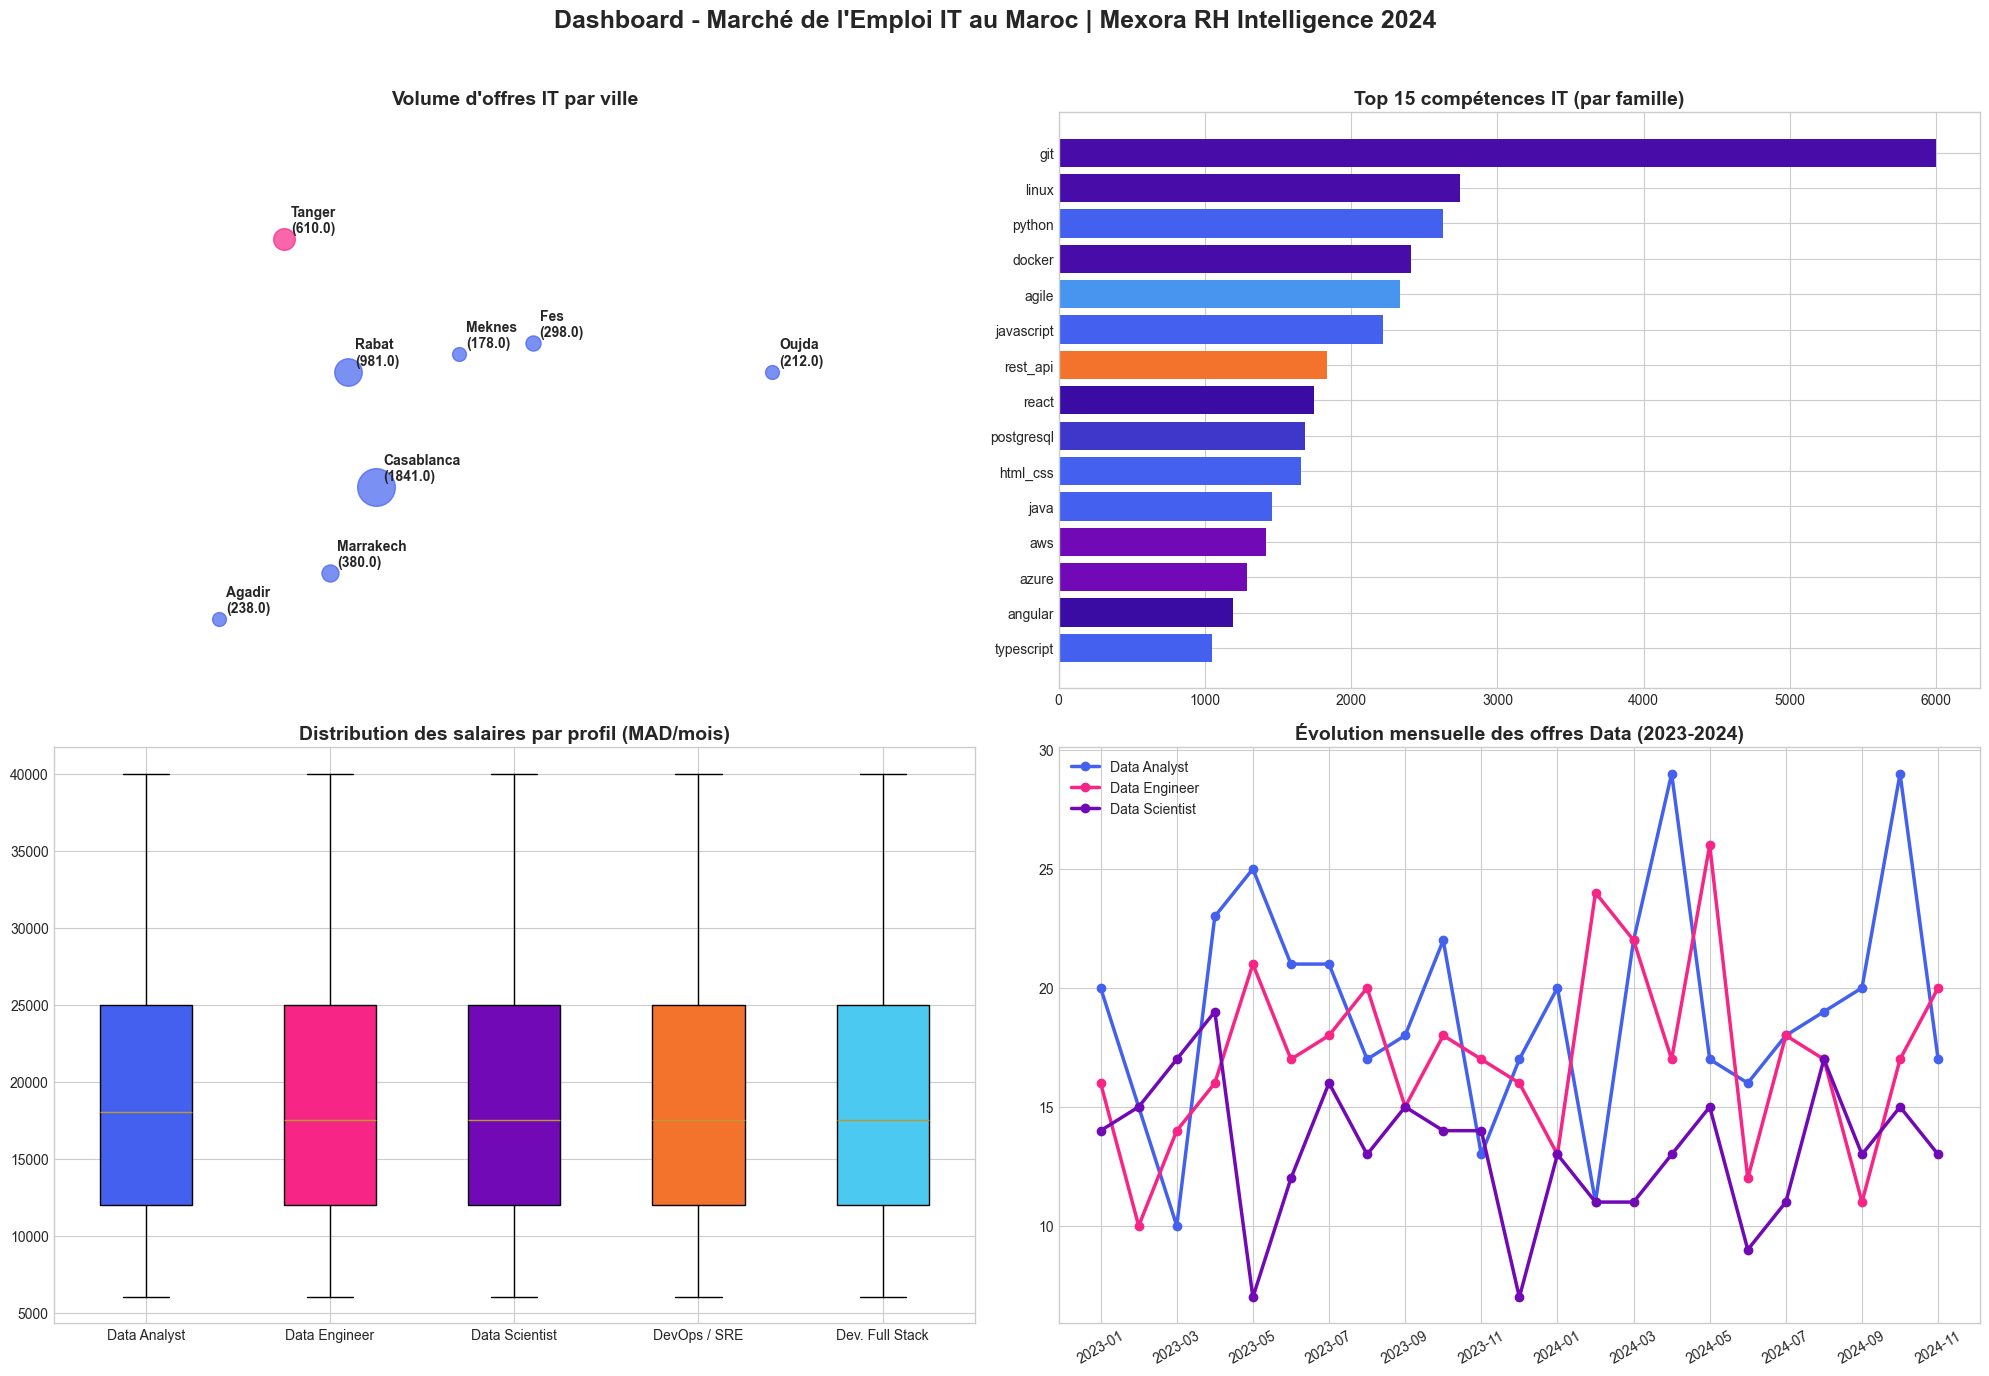

In [12]:
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    'langages': '#4361EE', 'frameworks_web': '#3A0CA3', 'data_engineering': '#F72585',
    'cloud': '#7209B7', 'bi_analytics': '#560BAD', 'devops_infra': '#480CA8',
    'databases': '#3F37C9', 'data_science_ml': '#4CC9F0', 'methodologies': '#4895EF',
    'securite': '#B5179E', 'autres': '#F3722C',
}
PROFIL_COLORS = {
    'Data Engineer': '#F72585', 'Data Analyst': '#4361EE', 'Data Scientist': '#7209B7',
    'Developpeur Full Stack': '#4CC9F0', 'Developpeur Backend': '#3A0CA3',
    'Developpeur Frontend': '#4895EF', 'DevOps / SRE': '#F3722C',
    'Cloud Engineer': '#560BAD', 'Developpeur Mobile': '#3F37C9',
    'Cybersecurite': '#B5179E', 'Chef de Projet IT': '#023E8A', 'Autre IT': '#888',
}

# 1. Villes
df_villes_map = con.execute("SELECT ville, SUM(nb_offres) AS nb FROM '../data_lake/gold/offres_par_ville.parquet' GROUP BY ville ORDER BY nb DESC LIMIT 10").df()
# 2. Competences
df_comp = con.execute("SELECT famille, competence, SUM(nb_offres_mentionnent) AS nb FROM '../data_lake/gold/top_competences.parquet' WHERE competence!='non_detecte' GROUP BY famille, competence ORDER BY nb DESC LIMIT 15").df()
# 3. Boxplot Salaires
df_box2 = con.execute("SELECT profil_normalise AS profil, salaire_median_mad FROM '../data_lake/silver/offres_clean/offres_clean.parquet' WHERE salaire_connu=true AND salaire_median_mad IS NOT NULL AND profil_normalise IN ('Data Engineer','Data Analyst','Data Scientist','Developpeur Full Stack','DevOps / SRE')").df()
# 4. Tendances
df_tendances = con.execute("SELECT annee||'-'||mois AS periode, profil, SUM(nb_offres) AS nb FROM '../data_lake/gold/tendances_mensuelles.parquet' WHERE profil IN ('Data Engineer','Data Analyst','Data Scientist') AND annee IS NOT NULL GROUP BY annee, mois, profil ORDER BY annee, mois").df()

fig = plt.figure(figsize=(20, 14))
fig.suptitle("Dashboard - Marché de l'Emploi IT au Maroc | Mexora RH Intelligence 2024", fontsize=18, fontweight='bold', y=0.98)

# AX1: Carte
ax1 = fig.add_subplot(2, 2, 1)
ville_coords = {'Casablanca': (0.35, 0.35), 'Rabat': (0.32, 0.55), 'Tanger': (0.25, 0.78), 'Marrakech': (0.30, 0.20), 'Fes': (0.52, 0.60), 'Agadir': (0.18, 0.12), 'Oujda': (0.78, 0.55), 'Meknes': (0.44, 0.58)}
for _, row in df_villes_map.iterrows():
    v = row['ville']
    if v in ville_coords:
        x, y = ville_coords[v]
        size = max(100, row['nb'] * 0.4)
        ax1.scatter(x, y, s=size, color='#F72585' if v == 'Tanger' else '#4361EE', alpha=0.7)
        ax1.annotate(f"{v}\n({row['nb']})", (x, y), textcoords="offset points", xytext=(5, 5), fontsize=10, fontweight='bold')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')
ax1.set_title("Volume d'offres IT par ville", fontweight='bold', fontsize=14)

# AX2: Competences
ax2 = fig.add_subplot(2, 2, 2)
bar_colors2 = [COLORS.get(f, '#888') for f in df_comp['famille']]
ax2.barh(df_comp['competence'][::-1], df_comp['nb'][::-1], color=bar_colors2[::-1])
ax2.set_title("Top 15 compétences IT (par famille)", fontweight='bold', fontsize=14)

# AX3: Boxplot
ax3 = fig.add_subplot(2, 2, 3)
profils_ord2 = df_box2.groupby('profil')['salaire_median_mad'].median().sort_values(ascending=False).index.tolist()
data_bp = [df_box2[df_box2['profil']==p]['salaire_median_mad'].dropna().values for p in profils_ord2]
bp2 = ax3.boxplot(data_bp, labels=[p.replace('Developpeur ','Dev. ') for p in profils_ord2], patch_artist=True)
for patch, p in zip(bp2['boxes'], profils_ord2):
    patch.set_facecolor(PROFIL_COLORS.get(p, '#888'))
ax3.set_title("Distribution des salaires par profil (MAD/mois)", fontweight='bold', fontsize=14)

# AX4: Tendances
ax4 = fig.add_subplot(2, 2, 4)
for profil, grp in df_tendances.groupby('profil'):
    ax4.plot(range(len(grp)), grp['nb'], marker='o', label=profil, color=PROFIL_COLORS.get(profil,'#888'), linewidth=2.5)
periodes = df_tendances['periode'].unique()
step = max(1, len(periodes)//8)
ax4.set_xticks(range(0, len(periodes), step))
ax4.set_xticklabels(list(periodes)[::step], rotation=30)
ax4.set_title("Évolution mensuelle des offres Data (2023-2024)", fontweight='bold', fontsize=14)
ax4.legend()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
